Libraries


In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import pickle

Firs we should call some var from data cleaning process.

In [2]:
%store -r df
df = df

%store -r numeric_columns
numeric_columns = numeric_columns

Handling Outlier

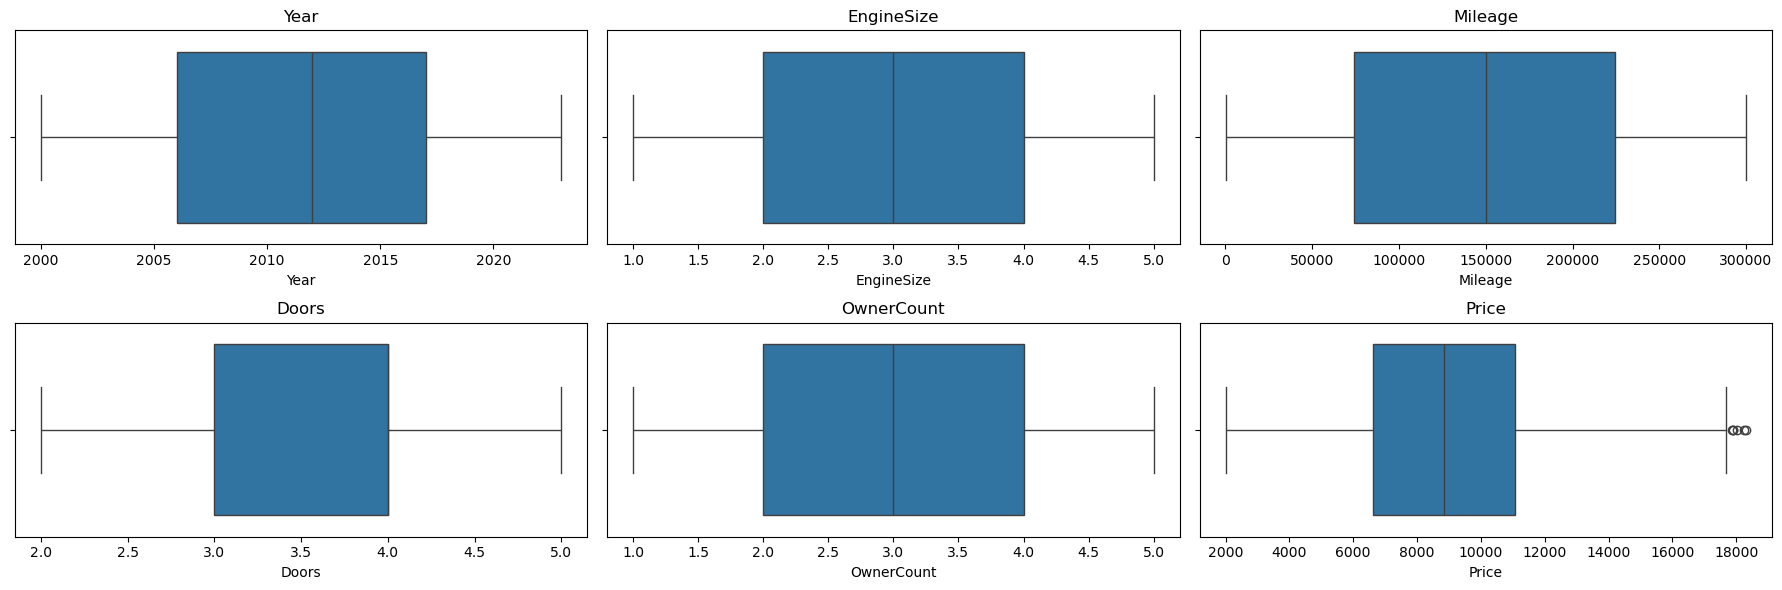

In [3]:
def box_plot(columns):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 6))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f'{col}')
    plt.tight_layout()
    plt.show()


# Example usage
box_plot(numeric_columns[:6])

we see, we have only a few outlier in price and just because its target, we can skip it and after transformation that issu will be gone

# Categorical Encoding
# Mean-Target Encoding

# Since Brand and Model have many unique values
# (high cardinality), we use Mean Target Encoding for them.

# Steps:
# 1. Calculate the mean target (Price) for each category
# 2. Replace each category with its corresponding mean price

In [4]:
#Brand
brand_mean_price = df.groupby('Brand')['Price'].mean()
df['Encoded Brand'] = df['Brand'].map(brand_mean_price)

# Model
model_mean_price = df.groupby('Model')['Price'].mean()
df['Encoded Model'] = df['Model'].map(model_mean_price)

# Drop original columns
df.drop(['Brand', 'Model'], axis=1, inplace=True)

# Now, we should save it for future usage

In [5]:
with open('../../models/Brand_Encoder.pkl', 'wb') as f:
    pickle.dump(brand_mean_price, f)

with open('../../models/Model_Encoder.pkl', 'wb') as f:
    pickle.dump(model_mean_price, f)

ONE HOT ENCODING

Now, for Transmission and Fuel,since they do not have high cardinality, we can use One-Hot Encoding.

In [6]:
# Select categorical columns to encode
categorical_cols = ['Fuel', 'Transmission']

# Define OneHot Encoder
encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

# Fit and transform selected categorical columns
encoded_array = encoder.fit_transform(df[categorical_cols])


# Convert encoded array to DataFrame
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(categorical_cols)
)

# Drop original categorical columns
# and merge encoded columns
df_encoded = df.drop(columns=categorical_cols).reset_index(drop=True)
df = pd.concat([df_encoded, encoded_df], axis=1)

NOW, we should save encoder for test and unseen data

In [ ]:
with open('../../models/OneHot_Encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

CHECKPOINT


In [8]:
%store df

Stored 'df' (DataFrame)
